In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from scipy.stats import energy_distance, wasserstein_distance
from scipy.stats import ks_2samp

<span style="color: orange; font-size: 30px;">Bivariate Gaussian Distribution Visualiazation</span>

At first I use matplotlib to plot the 2D normal distribution. 

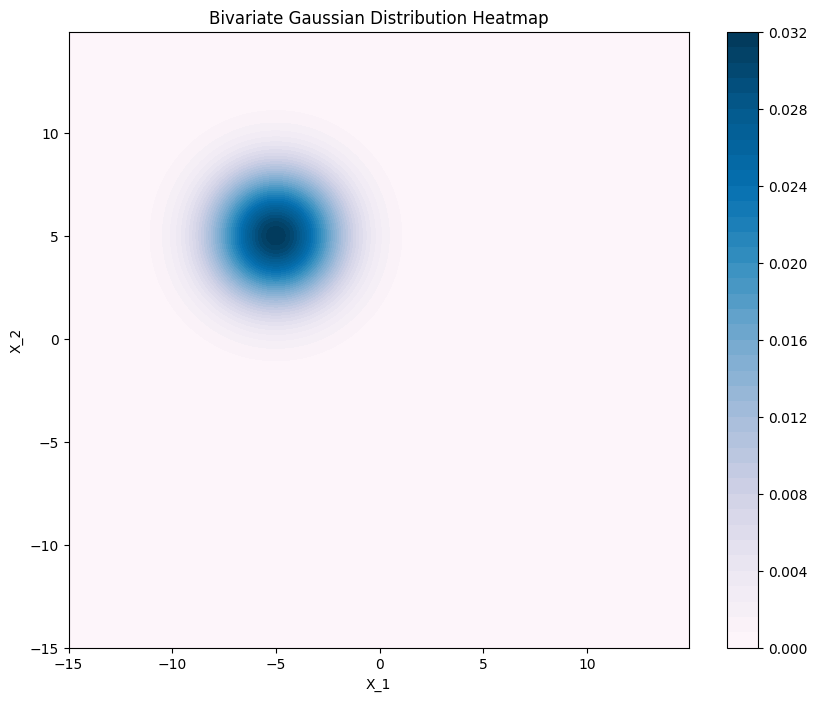

In [6]:
mean = np.array([-5, 5])
cov = 5 * np.eye(2) 

gaussian_distribution = multivariate_normal(mean=mean, cov=cov)

x_dist, y_dist = np.mgrid[-15:15:0.1, -15:15:0.1]
pos = np.dstack((x_dist, y_dist))
pdf = gaussian_distribution.pdf(pos)

plt.figure(figsize=(10, 8))
plt.contourf(x_dist, y_dist, pdf, levels=50, cmap='PuBu')
plt.colorbar()
plt.title('Bivariate Gaussian Distribution Heatmap')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.show()

<span style="color: orange; font-size: 30px;">Calculating and Visualizing The Score Function</span>

#### **1. Probability Density Function (PDF):**
For a bivariate Gaussian distribution with mean = $\boldsymbol{\mu}$ and covariance matrix = $\boldsymbol{\Sigma}$ we have:

$$
p(\mathbf{x}) = \frac{1}{2\pi |\boldsymbol{\Sigma}|^{1/2}} \exp\left(-\frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})\right)
$$

---

#### **2. Calculating The Potenial Function:**
First we calculate the potenial function which equals the log of PDF function.

$$
\log p(\mathbf{x}) = \underbrace{-\log(2\pi)}_{\text{constant}} - \frac{1}{2} \log|\boldsymbol{\Sigma}| - \frac{1}{2} (\mathbf{x} - \boldsymbol{\mu})^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})
$$

---

#### **3. Score Function Calculation:**
The score function is equal to the deravitive of potential function $\log p(\mathbf{x})$ with respect to $\mathbf{x}$:

$$
\nabla_{\mathbf{x}} \log p(\mathbf{x}) = -\boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu})
$$

This derivation need linear algebra to calculate.

---

##### **4. In This Case:**
Because the matrix is symmetrical:

if $\boldsymbol{\Sigma} = \begin{bmatrix} \sigma_1^2 & 0 \\ 0 & \sigma_2^2 \end{bmatrix}$, then:

$$
\boldsymbol{\Sigma}^{-1} = \begin{bmatrix} \frac{1}{\sigma_1^2} & 0 \\ 0 & \frac{1}{\sigma_2^2} \end{bmatrix}
$$

So the score function will be:

$$
\nabla_{\mathbf{x}} \log p(\mathbf{x}) = S(\mathbf{x}) = -\begin{bmatrix} \frac{x_1 - \mu_1}{\sigma_1^2} \\ \frac{x_2 - \mu_2}{\sigma_2^2} \end{bmatrix}
$$

---

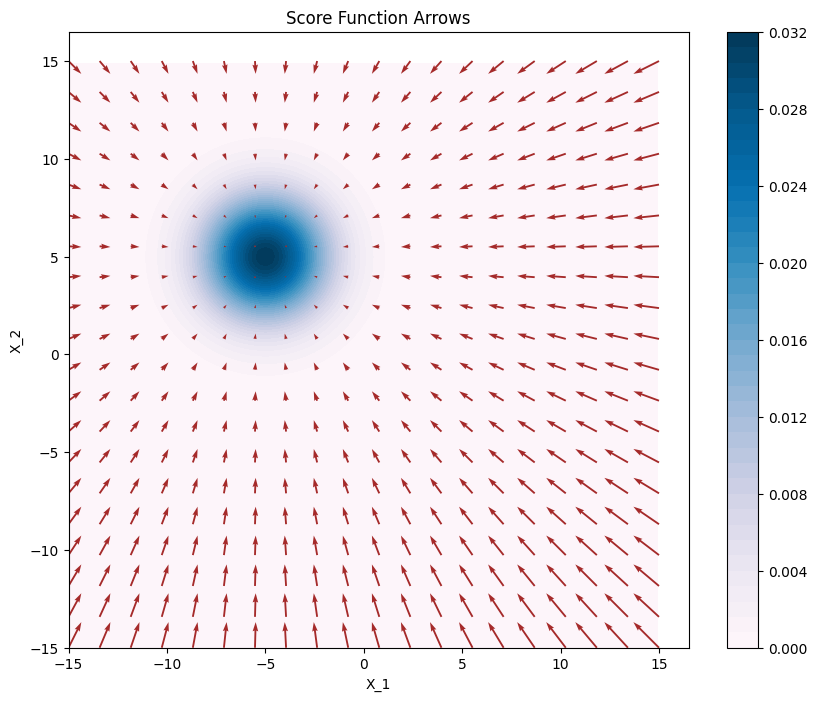

In [7]:
def score_function(x1, x2):
    return [(-1/5) * (5 + x1), (-1/5) * (x2 - 5)]

x1_grid, x2_grid = np.meshgrid(np.linspace(-15, 15, 20), np.linspace(-15, 15, 20))
u, v = score_function(x1_grid, x2_grid)

plt.figure(figsize=(10, 8))
plt.contourf(x_dist, y_dist, pdf, levels=50, cmap='PuBu')
plt.colorbar()
plt.quiver(x1_grid, x2_grid, u, v, color='brown')
plt.title('Score Function Arrows')
plt.xlabel('X_1')
plt.ylabel('X_2')
plt.show()

Now we implement the Langevin Dynamics algorithm:

In [ ]:
def langevin_dynamics(initial_points, num_of_moves=30, epsilon=0.1):
    samples = initial_points.copy()
    trajectory = [samples.copy()]
    
    for _ in range(num_of_moves):
        noise = np.random.normal(0, 1, size=samples.shape)
        grad_x, grad_y = score_function(samples[:, 0], samples[:, 1])
        samples[:, 0] += epsilon * grad_x + np.sqrt(2 * epsilon) * noise[:, 0]
        samples[:, 1] += epsilon * grad_y + np.sqrt(2 * epsilon) * noise[:, 1]
        trajectory.append(samples.copy())
    
    return samples, np.array(trajectory)

Now let's run the algorithm and see the trajectory of the sampling!

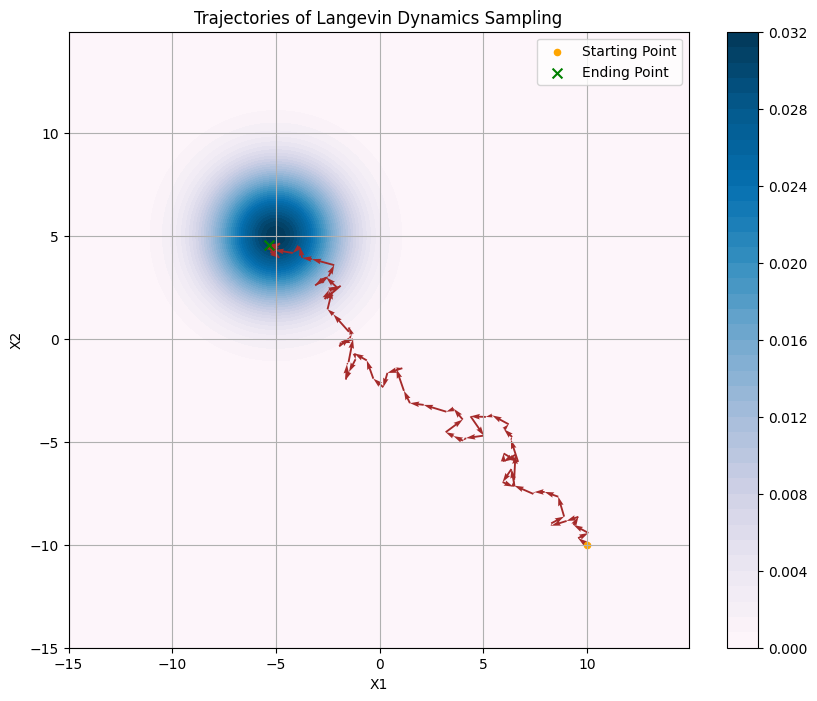

In [ ]:
num_of_moves = 80
num_of_samples = 1
initial_points = np.random.uniform(low=[-15, 0], high=[0, 15], size=(num_of_samples, 2))
initial_points[0] = [10, -10] #For showing a long path :)
samples, trajectory = langevin_dynamics(initial_points, num_of_moves)

plt.figure(figsize=(10, 8))
plt.contourf(x_dist, y_dist, pdf, levels=50, cmap='PuBu')
plt.colorbar()

for i in range(len(trajectory)-1):
    dx = trajectory[i+1][0][0] - trajectory[i][0][0]
    dy = trajectory[i+1][0][1] - trajectory[i][0][1]
    plt.quiver(trajectory[i][0][0], trajectory[i][0][1], dx, dy,
               color='brown', angles='xy', scale_units='xy', scale=1,
               width=0.003, headwidth=3, headlength=5)

starting_point = plt.scatter(trajectory[0, 0, 0], trajectory[0, 0, 1], c="orange", s=20)
ending_point = plt.scatter(trajectory[num_of_moves, 0, 0], trajectory[num_of_moves, 0, 1], c="green", s=50, marker='x')
starting_point.set_label("Starting Point")
ending_point.set_label("Ending Point")

plt.legend()
plt.title('Trajectories of Langevin Dynamics Sampling')
plt.xlabel('X1')
plt.ylabel('X2')
plt.grid()
plt.show()

<span style="color: orange; font-size: 30px;">Evaluating The Produced Sampling</span>

Now we do a sampling on both the real gaussian distribution and the produced distribution. Then we'll compare them and evaluate the algorithm.

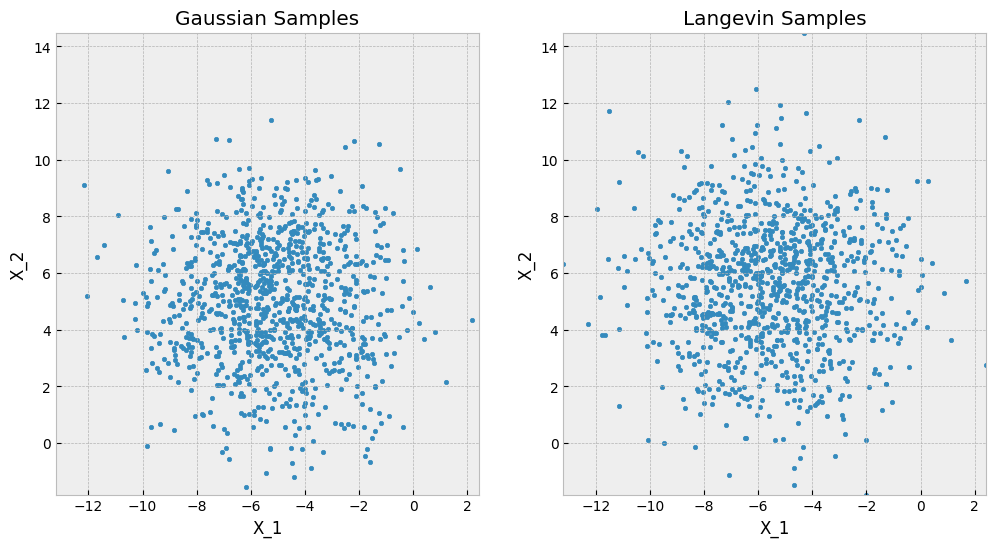

In [94]:
num_of_samples = 1000
initial_points = np.random.uniform(low=[-15, 0], high=[0, 15], size=(num_of_samples, 2))
langevin_samples, trajectory = langevin_dynamics(initial_points, num_of_moves)
gaussian_samples = np.random.multivariate_normal(mean, cov, num_of_samples)
plt.figure(figsize=(12, 6))

x_min = min(np.min(gaussian_samples[:, 0]), np.min(langevin_samples[:, 0]))
x_max = max(np.max(gaussian_samples[:, 0]), np.max(langevin_samples[:, 0]))
y_min = min(np.min(gaussian_samples[:, 1]), np.min(langevin_samples[:, 1]))
y_max = max(np.max(gaussian_samples[:, 1]), np.max(langevin_samples[:, 1]))
plt.style.use('bmh')
plt.subplot(1, 2, 1)
plt.title("Gaussian Samples")
plt.xlabel("X_1")
plt.ylabel("X_2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.scatter(gaussian_samples[:, 0], gaussian_samples[:, 1], s = 10)

plt.subplot(1, 2, 2)
plt.title("Langevin Samples")
plt.xlabel("X_1")
plt.ylabel("X_2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], s = 10)
plt.style.use('default')


<span style="color: blue; font-size: 20px;">Other Ways To Compare The Distributions</span>

To compare the distribution of the samples there are some other ways than visualization.

One way is to compare the statistics of the both distributions. As we can see below the cell code, the moments of the functions are approximately the same.

In [95]:
def compare_moments(samples1, samples2):
    print(f"{'Langevin':<22} {'Gaussian':<15}")
    print("-" * 45)
    for i, dim in enumerate(['X', 'Y']):
        print(f"Mean {dim}: {samples1[:, i].mean():<15.4f} {samples2[:, i].mean():<15.4f}")
        print(f"Var {dim}:  {samples1[:, i].var():<15.4f} {samples2[:, i].var():<15.4f}")
    print(f"Covariance:\n{np.cov(samples1.T)}\nvs\n{np.cov(samples2.T)}")

compare_moments(langevin_samples, gaussian_samples)


Langevin               Gaussian       
---------------------------------------------
Mean X: -5.5285         -5.1739        
Var X:  5.6483          5.0821         
Mean Y: 5.5391          4.9717         
Var Y:  5.3109          4.9173         
Covariance:
[[ 5.65391992 -0.07539778]
 [-0.07539778  5.31623585]]
vs
[[ 5.08714604 -0.13171011]
 [-0.13171011  4.92220492]]


### Comparison Matrics

There are some measures that similarity of them might cause the similarity of the distributions. I've used two of them here. As we can see, both the distances are close considerably.

In [96]:
# Compare each dimension separately
for dim in [0, 1]:
    ld_dim = langevin_samples[:, dim]
    true_dim = gaussian_samples[:, dim]
    
    print(f"Dimension {'X' if dim == 0 else 'Y'}:")
    print(f"  Energy Distance: {energy_distance(ld_dim, true_dim):.4f}")
    print(f"  Wasserstein Distance: {wasserstein_distance(ld_dim, true_dim):.4f}")

Dimension X:
  Energy Distance: 0.1907
  Wasserstein Distance: 0.3649
Dimension Y:
  Energy Distance: 0.2829
  Wasserstein Distance: 0.5686


### Multivariate Kolmogorov-Smirnov Statistical Test

We can also use Kolmogorov-Smirnov Statistical Test which shows how much two distributions are similar.

In [97]:
# Compare marginal distributions for each dimension
ks_x1 = ks_2samp(langevin_samples[:, 0], gaussian_samples[:, 0])
ks_x2 = ks_2samp(langevin_samples[:, 1], gaussian_samples[:, 1])
print(f"X1-axis KS statistic: {ks_x1.statistic:.4f}, p-value: {ks_x1.pvalue:.4f}")
print(f"X2-axis KS statistic: {ks_x2.statistic:.4f}, p-value: {ks_x2.pvalue:.4f}")

X1-axis KS statistic: 0.0910, p-value: 0.0005
X2-axis KS statistic: 0.1180, p-value: 0.0000


<span style="color: red; font-size: 30px;">Bonus Question</span>

The general answer is NO. But under some conditions we might be able to. 

If the two normal distributions had far means, it'll cause the mixture of them to have two modes. This will make a bad problem. Because the gradient of log(p(x)) is so close to 0 at a mode of function, when the algorithm reaches a peak it'll get stuck in it. This may stop the algorithm from progressing and discover the other parts of the distribution and make the sampling invalid. 

If the p(x) function had two close modes it would be probable for the langevin dynamics algorithm to be efficient and accurate. But we can't guarantee that. So I answer this question with "No."